# Mean-Reversion Strategy — Results

DJ30 universe · Daily data 2014–2026 · CAPM residual z-score signal · Top-3 long-only · Weekly rebalance

**Splits:** Train 2014–2019 | Val 2020–2022 | Test 2023–2025

In [1]:
import shutil
shutil.rmtree("data",   ignore_errors=True)
shutil.rmtree("models", ignore_errors=True)
print("Cache cleared.")

Cache cleared.


In [2]:
import sys, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

DATA_DIR  = Path("data")
MODEL_DIR = Path("models")

TRAIN_END = "2019-12-31"
VAL_END   = "2022-12-31"
TEST_END  = "2025-12-31"
SPLITS = {
    "Train": (None,       TRAIN_END),
    "Val":   (TRAIN_END,  VAL_END),
    "Test":  (VAL_END,    TEST_END),
}
COLORS = {"Train": "#4C72B0", "Val": "#DD8452", "Test": "#55A868"}

## 1. Run Pipeline (skip if cache exists)

In [ ]:
from data_download import download_prices, compute_returns
from data_prep    import load_ff_factors, build_features
from portfolio    import build_weights

prices  = download_prices()
returns = compute_returns(prices)
ff      = load_ff_factors()
_, _, zscores = build_features(returns, ff)
weights = build_weights(zscores)
print("Pipeline complete.")

## 4. Portfolio Statistics

In [ ]:
def sharpe(pnl, ann=252):
    return pnl.mean() / pnl.std() * np.sqrt(ann) if pnl.std() > 0 else np.nan

def max_dd(pnl):
    wealth = np.exp(pnl.cumsum())
    return (wealth / wealth.cummax() - 1).min()

def avg_turnover(w):
    return w.diff().abs().sum(axis=1).mean()

def pct_active(w):
    return (w != 0).sum(axis=1).mean()

# Portfolio daily PnL: weights[t] · returns[t+1]
fwd_ret = returns.shift(-1)
common  = weights.index.intersection(fwd_ret.index)
pnl     = (weights.loc[common] * fwd_ret.loc[common].reindex(columns=weights.columns, fill_value=0)).sum(axis=1)

rows = []
for name, (start, end) in SPLITS.items():
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub   = pnl[mask]
    sub_w = weights.loc[weights.index.isin(sub.index)]
    rows.append({
        "Split":         name,
        "Ann. Return":   np.exp(sub.mean() * 252) - 1,
        "Ann. Sharpe":   sharpe(sub),
        "Max Drawdown":  max_dd(sub),
        "Avg Turnover":  avg_turnover(sub_w),
        "Avg Positions": pct_active(sub_w),
    })

stats = pd.DataFrame(rows).set_index("Split")
stats.style.format({
    "Ann. Return":   "{:.2%}",
    "Ann. Sharpe":   "{:.3f}",
    "Max Drawdown":  "{:.2%}",
    "Avg Turnover":  "{:.4f}",
    "Avg Positions": "{:.1f}",
})

## 5. Equity Curves

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
fig.suptitle("Mean-Reversion Strategy — Equity Curves (cumulative return)", fontsize=13)

for ax, (name, (start, end)) in zip(axes, SPLITS.items()):
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub    = pnl[mask]
    wealth = np.exp(sub.cumsum())
    cum    = wealth - 1                    # real compounded return
    dd     = wealth / wealth.cummax() - 1  # real peak-to-trough drawdown

    color = COLORS[name]
    ax.fill_between(dd.index, dd.values, 0, alpha=0.25, color="red")
    ax.plot(cum.index, cum.values, color=color, lw=1.4, label="Cum. return")
    ax.axhline(0, color="grey", lw=0.6, ls="--")
    ax.set_title(f"{name}  |  Sharpe={sharpe(sub):.2f}  MaxDD={max_dd(sub):.2%}", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_ylabel("Cum. return")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

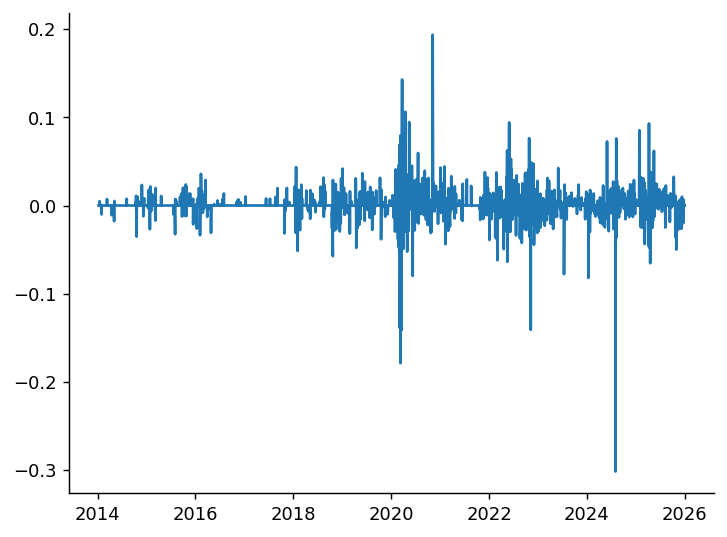

In [10]:
plt.plot(pnl)

In [33]:
pnl.sort_values(ascending=False)[:10]

2020-11-06    0.193821
2020-03-23    0.143001
2020-04-16    0.106276
2020-05-15    0.094687
2022-05-31    0.094209
2025-04-08    0.093155
2025-01-27    0.085497
2020-04-03    0.081141
2020-03-12    0.079675
2022-10-27    0.076379
dtype: float64

In [34]:
weights.loc["2020-11-06"].sort_values(ascending=False)

AXP     1.0
AAPL    0.0
PG      0.0
MMM     0.0
MRK     0.0
MSFT    0.0
NKE     0.0
NVDA    0.0
PFE     0.0
SHW     0.0
KO      0.0
T       0.0
TRV     0.0
UNH     0.0
V       0.0
VZ      0.0
WMT     0.0
MCD     0.0
JPM     0.0
AMGN    0.0
DD      0.0
AMZN    0.0
BA      0.0
CAT     0.0
CRM     0.0
CSCO    0.0
CVX     0.0
DIS     0.0
JNJ     0.0
GE      0.0
GS      0.0
HD      0.0
HON     0.0
IBM     0.0
INTC    0.0
XOM     0.0
Name: 2020-11-06 00:00:00, dtype: float64

## 6. Rolling Sharpe (252-day window)

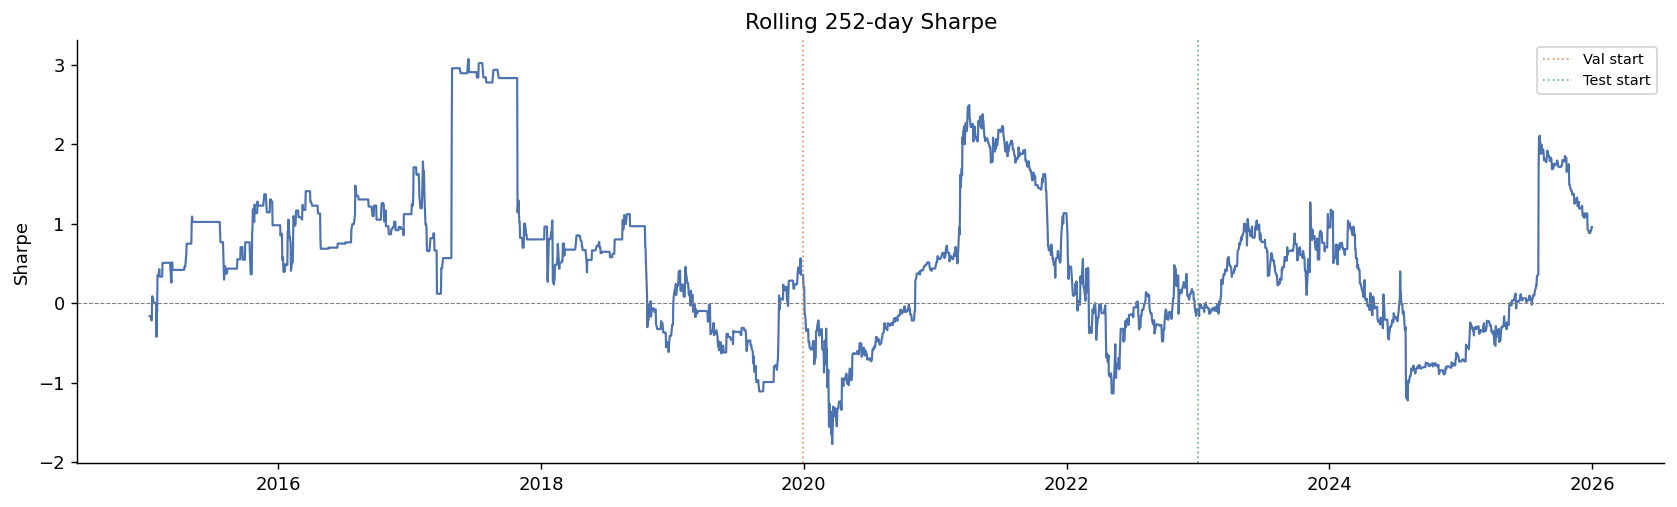

In [8]:
roll_sr = pnl.rolling(252).apply(lambda x: sharpe(pd.Series(x)), raw=False)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_sr.index, roll_sr.values, lw=1.2, color="#4C72B0")
ax.axhline(0, color="grey", lw=0.6, ls="--")
for name, (start, end) in SPLITS.items():
    if start: ax.axvline(pd.Timestamp(start), color=COLORS[name], lw=1, ls=":", alpha=0.8, label=f"{name} start")
ax.set_title("Rolling 252-day Sharpe"); ax.set_ylabel("Sharpe"); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

## 7. Daily Return Distribution

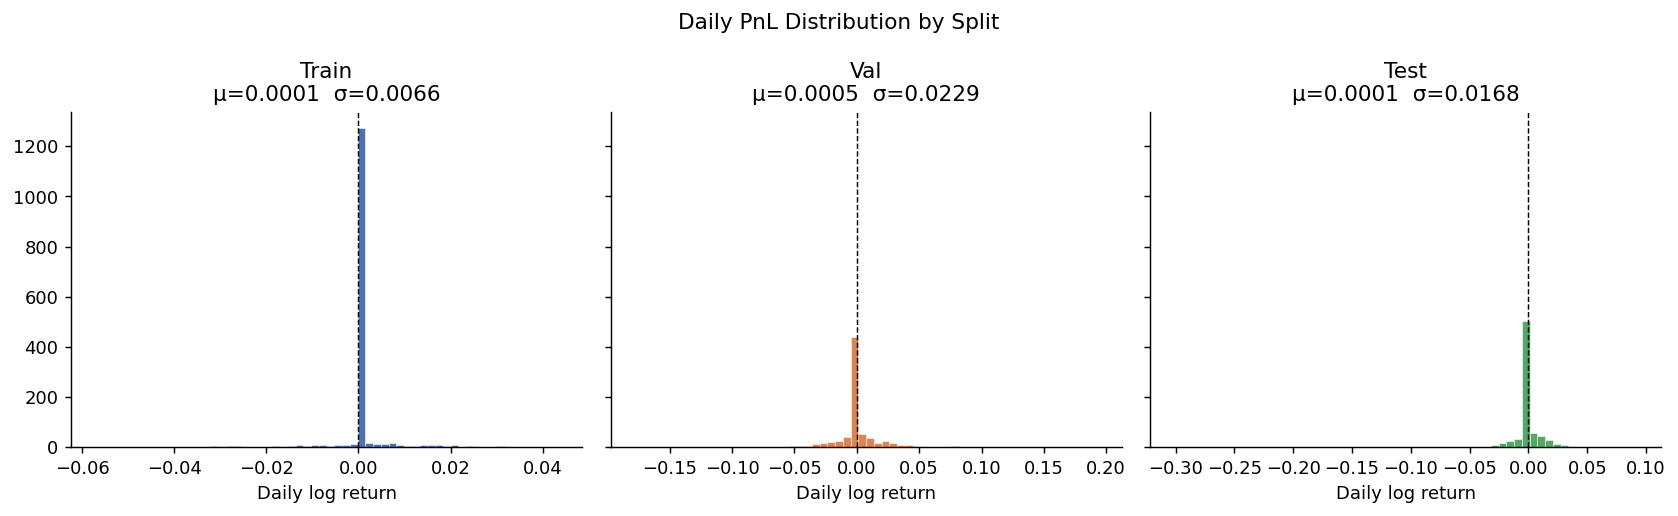

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.suptitle("Daily PnL Distribution by Split", fontsize=12)

for ax, (name, (start, end)) in zip(axes, SPLITS.items()):
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub = pnl[mask]
    ax.hist(sub, bins=60, color=COLORS[name], edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_title(f"{name}\nμ={sub.mean():.4f}  σ={sub.std():.4f}")
    ax.set_xlabel("Daily log return")

plt.tight_layout(); plt.show()